# HW4 — Question 1: OLS on `us_macro_quarterly.xlsx`

**IEOR 4578 — Forecasting**
Luca Barattini (UNI: LB3656)

This notebook works through every sub-part of HW4 Question 1. Outputs are printed in table form so they can be copied straight into the Overleaf write-up.


## Question statement

Run the OLS-related code in `GLM.py` for `us_macro_quarterly.xlsx`.

1. Explain the model summary when all the data is fit. Discuss R², Df Residuals, Df Model, Method, F-statistic, Prob(F-statistic), Log-Likelihood, AIC, BIC, Coef, Std err, t, and P>|t|.
2. Compute the t-value for each parameter (including the constant) using the lecture equation.
3. Run `t_score_probability` to find the probability of the null hypothesis for each parameter's t-value; list which are statistically significant.
4. Using $t_{\alpha/2}$ with $\alpha = 0.05$, compute the lower and upper CI for the constant, $\beta_4$, and $\beta_6$.
5. Run with the ordered train-test split and compare the test results with the model fitted on the entire data.
6. Run all three variations of ANOVA and discuss SSR, df_diff, ss_diff, df_resid, F, and Pr(>F).
7. Submit appropriately labelled visuals.


In [1]:
# Imports — trimmed to only what Q1 actually needs
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm
from scipy.stats import t

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

os.makedirs("images", exist_ok=True)


In [2]:
# Load the data
df = pd.read_excel('Datasets/us_macro_quarterly.xlsx')
print("Shape  :", df.shape)
print("Columns:", list(df.columns))

# The 'Date' column is stored as strings like '1959:01' (year:quarter).
# Parse to proper datetime so matplotlib can lay out sparse, readable ticks
# instead of printing all 220 rows on top of each other.
df['Date_dt'] = pd.PeriodIndex(
    df['Date'].str.replace(':0', 'Q', regex=False),
    freq='Q'
).to_timestamp()
print("\nFirst/last parsed dates:", df['Date_dt'].iloc[0], '→', df['Date_dt'].iloc[-1])
df.head()


Shape  : (220, 10)
Columns: ['Date', 'GDPC96', 'JAPAN_IP', 'PCECTPI', 'GS10', 'GS1', 'TB3MS', 'UNRATE', 'EXUSUK', 'CPIAUCSL']

First/last parsed dates: 1959-01-01 00:00:00 → 2013-10-01 00:00:00


/Users/lucabarattini/Coding/IEOR-4578/.venv/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Date,GDPC96,JAPAN_IP,PCECTPI,GS10,GS1,TB3MS,UNRATE,EXUSUK,CPIAUCSL,Date_dt
0,1959:01,2973.782,9.425179,17.137,3.990000,3.503333,2.773333,5.833333,2.809507,28.993333,1959-01-01
1,1959:02,3046.096,10.080844,17.204,4.256667,3.916667,3.000000,5.100000,2.814537,29.043333,1959-04-01
2,1959:03,3040.235,10.681870,17.307,4.503333,4.603333,3.540000,5.266667,2.808283,29.193333,1959-07-01
3,1959:04,3052.194,11.419493,17.401,4.583333,4.916667,4.230000,5.600000,2.802463,29.370000,1959-10-01
4,1960:01,3120.195,12.184435,17.424,4.486667,4.570000,3.873333,5.133333,2.802970,29.396667,1960-01-01


## Part 1 — Fit the full-sample OLS model

Target: `PCECTPI` (Personal Consumption Expenditures Chain-type Price Index).
Regressors: `JAPAN_IP`, `GS10`, `GS1`, `TB3MS`, `UNRATE`, `EXUSUK`.

With `sm.add_constant`, the coefficient layout is:

| Index | Symbol | Variable |
|-------|--------|----------|
| 0 | $\beta_0$ | const |
| 1 | $\beta_1$ | JAPAN_IP |
| 2 | $\beta_2$ | GS10 |
| 3 | $\beta_3$ | GS1 |
| 4 | $\beta_4$ | TB3MS |
| 5 | $\beta_5$ | UNRATE |
| 6 | $\beta_6$ | EXUSUK |


In [3]:
regressors = ['JAPAN_IP', 'GS10', 'GS1', 'TB3MS', 'UNRATE', 'EXUSUK']
xdata = df.loc[:, regressors].values
ydata = df.loc[:, 'PCECTPI'].values
xdata = sm.add_constant(xdata)          # prepend intercept column
param_names = ['const'] + regressors

model_full = sm.OLS(ydata, xdata).fit()
print(model_full.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     766.5
Date:                Fri, 10 Apr 2026   Prob (F-statistic):          3.40e-141
Time:                        17:49:05   Log-Likelihood:                -716.96
No. Observations:                 220   AIC:                             1448.
Df Residuals:                     213   BIC:                             1472.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         19.8404      7.586      2.615      0.0

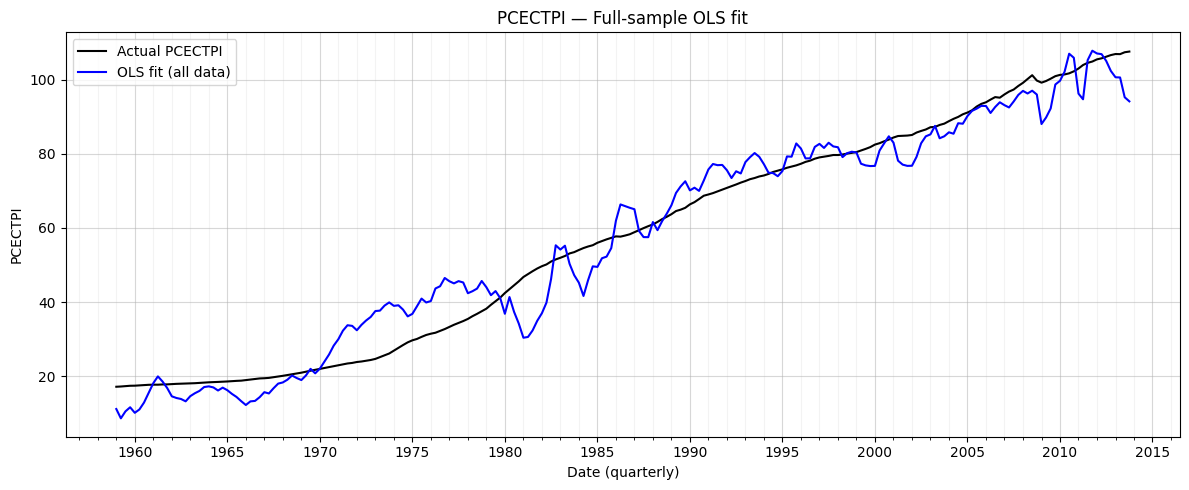

In [4]:
# Visual — Actual PCECTPI vs full-sample OLS fit
predictions_full = model_full.predict(xdata)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['Date_dt'], ydata,            'k', linewidth=1.5, label='Actual PCECTPI')
ax.plot(df['Date_dt'], predictions_full, 'b', linewidth=1.5, label='OLS fit (all data)')

# Readable date ticks — major every 5 years, minor every year
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))

ax.set_xlabel('Date (quarterly)'); ax.set_ylabel('PCECTPI')
ax.set_title('PCECTPI — Full-sample OLS fit')
ax.legend(loc='upper left'); ax.grid(True, which='major', alpha=0.5)
ax.grid(True, which='minor', alpha=0.15)
plt.tight_layout()
plt.savefig('images/Q1_full_fit.png', dpi=130)
plt.show()


### Key summary statistics (extracted programmatically for the write-up)


In [5]:
summary_stats = {
    'Method'            : 'Least Squares',
    'n observations'    : int(model_full.nobs),
    'Df Model'          : int(model_full.df_model),
    'Df Residuals'      : int(model_full.df_resid),
    'R-squared'         : model_full.rsquared,
    'Adj. R-squared'    : model_full.rsquared_adj,
    'F-statistic'       : model_full.fvalue,
    'Prob (F-statistic)': model_full.f_pvalue,
    'Log-Likelihood'    : model_full.llf,
    'AIC'               : model_full.aic,
    'BIC'               : model_full.bic,
    'RSS'               : float(np.sum(model_full.resid**2)),
}
for k, v in summary_stats.items():
    print(f"{k:22s} = {v}")


Method                 = Least Squares
n observations         = 220
Df Model               = 6
Df Residuals           = 213
R-squared              = 0.9557354538611644
Adj. R-squared         = 0.9544885652375352
F-statistic            = 766.4962497447598
Prob (F-statistic)     = 3.402698558521447e-141
Log-Likelihood         = -716.9641456118795
AIC                    = 1447.928291223759
BIC                    = 1471.6836840482256
RSS                    = 8722.021811474659


## Part 2 — Manually compute t-values

From lecture, for each coefficient:

$$t_i \;=\; \frac{\hat{\beta}_i}{\text{SE}(\hat{\beta}_i)}, \qquad \text{SE}(\hat{\beta}_i) \;=\; \sqrt{\hat{\sigma}^2 \; \left[(X^\top X)^{-1}\right]_{ii}}$$

with $\hat{\sigma}^2 = \mathrm{RSS}/(n-k)$ where $k$ is the number of parameters *including* the intercept.


In [6]:
n   = len(ydata)
k   = xdata.shape[1]
dof = n - k

beta_hat   = model_full.params
residuals  = ydata - model_full.predict(xdata)
RSS        = float(np.sum(residuals**2))
sigma2_hat = RSS / dof
XtX_inv    = np.linalg.inv(xdata.T @ xdata)
SE_manual  = np.sqrt(sigma2_hat * np.diag(XtX_inv))
t_manual   = beta_hat / SE_manual

print(f"n = {n},  k = {k},  dof = n-k = {dof}")
print(f"RSS = {RSS:.6f},  sigma^2_hat = {sigma2_hat:.6f}\n")

compare = pd.DataFrame({
    'Parameter'       : param_names,
    'Coef'            : beta_hat,
    'SE (manual)'     : SE_manual,
    'SE (statsmodels)': model_full.bse,
    't (manual)'      : t_manual,
    't (statsmodels)' : model_full.tvalues,
})
print(compare.to_string(index=False, float_format=lambda v: f'{v:12.6f}'))


n = 220,  k = 7,  dof = n-k = 213
RSS = 8722.021811,  sigma^2_hat = 40.948459

Parameter         Coef  SE (manual)  SE (statsmodels)   t (manual)  t (statsmodels)
    const    19.840410     7.585775          7.585775     2.615476         2.615476
 JAPAN_IP     0.814323     0.030905          0.030905    26.349530        26.349530
     GS10    -7.696645     0.824352          0.824352    -9.336602        -9.336602
      GS1     6.294430     1.839874          1.839874     3.421121         3.421121
    TB3MS    -3.182478     1.547065          1.547065    -2.057107        -2.057107
   UNRATE     3.875867     0.374901          0.374901    10.338381        10.338381
   EXUSUK    -7.655680     2.202423          2.202423    -3.476026        -3.476026


## Part 3 — p-values via `t_score_probability`

We re-declare the helper from `GLM.py` and evaluate it on every manually-computed t-value.


In [7]:
def t_score_probability(t_score, degrees_of_freedom):
    # Two-sided p-value for a given t-score under H0: beta_i = 0.
    p_value = t.sf(np.abs(t_score), degrees_of_freedom) * 2
    return p_value

alpha = 0.05
p_manual = np.array([t_score_probability(ti, dof) for ti in t_manual])
is_sig   = p_manual < alpha

sig_table = pd.DataFrame({
    'Parameter'             : param_names,
    'Coef'                  : beta_hat,
    't-value'               : t_manual,
    'p-value (manual)'      : p_manual,
    'p-value (statsmodels)' : model_full.pvalues,
    'Significant (α=0.05)'  : is_sig,
})
print(sig_table.to_string(index=False, float_format=lambda v: f'{v:12.6f}'))

sig_names    = [p for p, s in zip(param_names, is_sig) if s]
nonsig_names = [p for p, s in zip(param_names, is_sig) if not s]
print(f"\n>>> Significant at α=0.05 : {sig_names}")
print(f">>> NOT significant at α=0.05: {nonsig_names}")


Parameter         Coef      t-value  p-value (manual)  p-value (statsmodels)  Significant (α=0.05)
    const    19.840410     2.615476          0.009548               0.009548                  True
 JAPAN_IP     0.814323    26.349530          0.000000               0.000000                  True
     GS10    -7.696645    -9.336602          0.000000               0.000000                  True
      GS1     6.294430     3.421121          0.000748               0.000748                  True
    TB3MS    -3.182478    -2.057107          0.040894               0.040894                  True
   UNRATE     3.875867    10.338381          0.000000               0.000000                  True
   EXUSUK    -7.655680    -3.476026          0.000617               0.000617                  True

>>> Significant at α=0.05 : ['const', 'JAPAN_IP', 'GS10', 'GS1', 'TB3MS', 'UNRATE', 'EXUSUK']
>>> NOT significant at α=0.05: []


## Part 4 — 95% Confidence intervals for $\beta_0$ (const), $\beta_4$, and $\beta_6$

$$\hat{\beta}_i \;\pm\; t_{\alpha/2,\,n-k} \cdot \text{SE}(\hat{\beta}_i)$$

With the layout above: $\beta_0$ = const, $\beta_4$ = TB3MS, $\beta_6$ = EXUSUK.


In [8]:
alpha  = 0.05
t_crit = t.ppf(1 - alpha/2, dof)
print(f"t_(α/2, dof={dof}) = {t_crit:.6f}  (α = {alpha})\n")

ci_indices = [0, 4, 6]
ci_labels  = ['const (β0)', 'TB3MS (β4)', 'EXUSUK (β6)']

rows = []
for idx, lbl in zip(ci_indices, ci_labels):
    b  = beta_hat[idx]
    se = SE_manual[idx]
    lo = b - t_crit * se
    hi = b + t_crit * se
    rows.append([lbl, b, se, lo, hi])

ci_df = pd.DataFrame(rows, columns=['Parameter', 'Coef', 'SE', 'CI 95% lower', 'CI 95% upper'])
print(ci_df.to_string(index=False, float_format=lambda v: f'{v:12.6f}'))

# Cross-check with statsmodels' own .conf_int()
sm_ci = pd.DataFrame(model_full.conf_int(alpha=0.05), index=param_names, columns=['lower', 'upper'])
print('\nStatsmodels .conf_int(0.05) for the same three parameters:')
print(sm_ci.iloc[[0, 4, 6]])


t_(α/2, dof=213) = 1.971164  (α = 0.05)

  Parameter         Coef           SE  CI 95% lower  CI 95% upper
 const (β0)    19.840410     7.585775      4.887605     34.793216
 TB3MS (β4)    -3.182478     1.547065     -6.231996     -0.132960
EXUSUK (β6)    -7.655680     2.202423    -11.997017     -3.314343

Statsmodels .conf_int(0.05) for the same three parameters:
            lower      upper
const    4.887605  34.793216
TB3MS   -6.231996  -0.132960
EXUSUK -11.997017  -3.314343


## Part 5 — Ordered train/test split and comparison

Since `us_macro_quarterly.xlsx` is a time series, the ordering matters. We split the first 176 rows as train and the remaining as test (~80/20), exactly as in `GLM.py`.

> **Fix vs. `GLM.py`**: the original script had a typo (`y_train` vs `Y_train` casing) that re-used the random-split target. This notebook uses a single consistent lowercase name.


In [9]:
split = 176
X_train = xdata[:split]; X_test = xdata[split:]
y_train = ydata[:split]; y_test = ydata[split:]

model_train = sm.OLS(y_train, X_train).fit()
in_sample_pred  = model_train.predict(X_train)
out_sample_pred = model_train.predict(X_test)

def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat)**2)))

metrics = pd.DataFrame({
    'Model'         : ['Full-sample (all rows)', 'Train-only (first 176)'],
    'R²'            : [model_full.rsquared,     model_train.rsquared],
    'Adj R²'        : [model_full.rsquared_adj, model_train.rsquared_adj],
    'AIC'           : [model_full.aic,          model_train.aic],
    'BIC'           : [model_full.bic,          model_train.bic],
    'In-sample RMSE': [rmse(ydata, predictions_full), rmse(y_train, in_sample_pred)],
    'Test RMSE'     : [np.nan, rmse(y_test, out_sample_pred)],
})
print(metrics.to_string(index=False, float_format=lambda v: f'{v:12.4f}'))


                 Model           R²       Adj R²          AIC          BIC  In-sample RMSE    Test RMSE
Full-sample (all rows)       0.9557       0.9545    1447.9283    1471.6837          6.2965          NaN
Train-only (first 176)       0.9382       0.9360    1143.5909    1165.7842          5.9902      14.4276


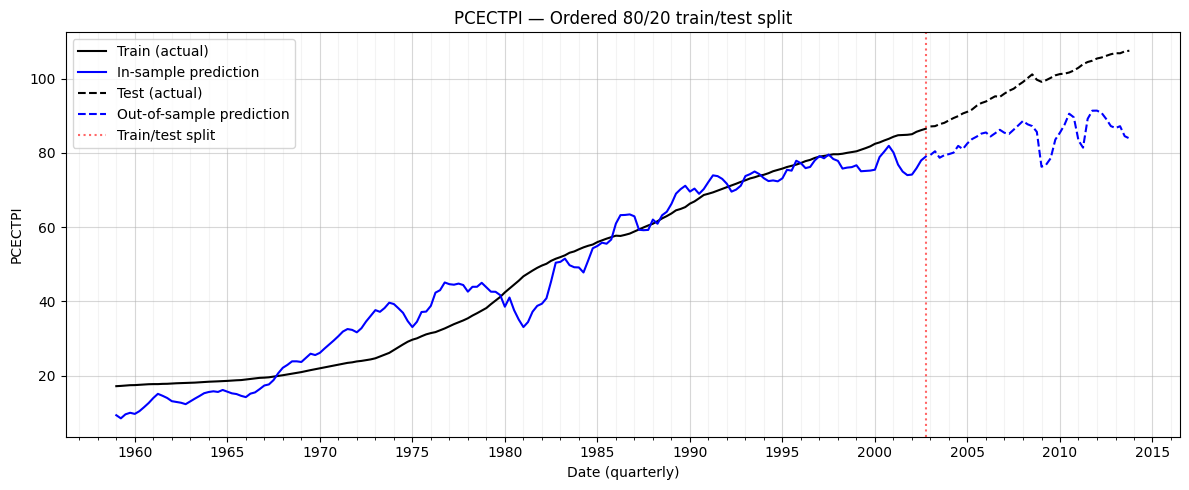

In [10]:
# Plot: train / test / in-sample / out-of-sample  (parsed datetime x-axis)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.loc[:split-1, 'Date_dt'], y_train,         'k',   linewidth=1.5, label='Train (actual)')
ax.plot(df.loc[:split-1, 'Date_dt'], in_sample_pred,  'b',   linewidth=1.5, label='In-sample prediction')
ax.plot(df.loc[split:,   'Date_dt'], y_test,          'k--', linewidth=1.5, label='Test (actual)')
ax.plot(df.loc[split:,   'Date_dt'], out_sample_pred, 'b--', linewidth=1.5, label='Out-of-sample prediction')
ax.axvline(df.loc[split-1, 'Date_dt'], color='red', linestyle=':', alpha=0.6, label='Train/test split')

# Readable date ticks — major every 5 years, minor every year
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))

ax.set_xlabel('Date (quarterly)'); ax.set_ylabel('PCECTPI')
ax.set_title('PCECTPI — Ordered 80/20 train/test split')
ax.legend(loc='upper left'); ax.grid(True, which='major', alpha=0.5)
ax.grid(True, which='minor', alpha=0.15)
plt.tight_layout()
plt.savefig('images/Q1_train_test.png', dpi=130)
plt.show()


In [11]:
# Summary of the train-only model — useful for the write-up
print(model_train.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     427.4
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           2.34e-99
Time:                        17:49:05   Log-Likelihood:                -564.80
No. Observations:                 176   AIC:                             1144.
Df Residuals:                     169   BIC:                             1166.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         31.9781      8.376      3.818      0.0

## Part 6 — Three ANOVA variations

`anova_lm` reports for each row:
- **ssr** — residual sum of squares of that model
- **df_resid** — residual degrees of freedom
- **ss_diff** — extra sum of squares explained by moving from the smaller to the larger model
- **df_diff** — difference in degrees of freedom between the two models
- **F, Pr(>F)** — F-statistic and corresponding p-value for the nested-model comparison

> **Fix vs. `GLM.py`**: the reduced model in the second ANOVA was missing `sm.add_constant`, so it wasn't properly nested inside the full model. This notebook adds the intercept back to make the nesting valid.


In [12]:
# ANOVA 1 — Full model vs intercept-only (null) model
print("=" * 72)
print("ANOVA 1 — Full model vs Intercept-only (null) model")
print("=" * 72)
intercept_only = sm.OLS(ydata, np.ones(len(ydata))).fit()
anova1 = anova_lm(intercept_only, model_full)
print(anova1)


ANOVA 1 — Full model vs Intercept-only (null) model
   df_resid            ssr  df_diff        ss_diff          F         Pr(>F)
0     219.0  197043.064310      0.0            NaN        NaN            NaN
1     213.0    8722.021811      6.0  188321.042498  766.49625  3.402699e-141


In [13]:
# ANOVA 2 — Reduced model (const + JAPAN_IP + UNRATE + EXUSUK) vs Full
print("=" * 72)
print("ANOVA 2 — Reduced (const, JAPAN_IP, UNRATE, EXUSUK) vs Full")
print("=" * 72)
X_reduced = sm.add_constant(df.loc[:, ['JAPAN_IP', 'UNRATE', 'EXUSUK']].values)
reduced_model = sm.OLS(ydata, X_reduced).fit()
anova2 = anova_lm(reduced_model, model_full, typ=1)
print(anova2)


ANOVA 2 — Reduced (const, JAPAN_IP, UNRATE, EXUSUK) vs Full
   df_resid           ssr  df_diff       ss_diff           F        Pr(>F)
0     216.0  29145.446498      0.0           NaN         NaN           NaN
1     213.0   8722.021811      3.0  20423.424686  166.253099  1.549676e-55


In [14]:
# ANOVA 3 — Full model vs itself (sanity check)
print("=" * 72)
print("ANOVA 3 — Full model vs itself")
print("=" * 72)
anova3 = anova_lm(model_full, model_full, typ=1)
print(anova3)


ANOVA 3 — Full model vs itself
   df_resid          ssr  df_diff  ss_diff   F  Pr(>F)
0     213.0  8722.021811      0.0      NaN NaN     NaN
1     213.0  8722.021811     -0.0     -0.0 NaN     NaN


### Reading the three ANOVAs (for the write-up)

- **ANOVA 1** compares the 6-regressor full model to the null model that predicts $\bar{y}$. The resulting F-statistic equals the `F-statistic` printed at the top of `model_full.summary()`; a tiny `Pr(>F)` means the regressors jointly explain a large share of variance.
- **ANOVA 2** tests whether dropping the three interest-rate variables (`GS10`, `GS1`, `TB3MS`) significantly worsens the fit. The `ss_diff` row is the extra sum of squares attributable to those three rates; the F-statistic is built from `(ss_diff / df_diff) / (ssr_full / df_resid_full)`.
- **ANOVA 3** compares the full model to itself: `ss_diff = 0`, `df_diff = 0`, and `F` is `NaN`. It is only a structural/sanity check.
